## Data Exploration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.modeling_common import load_adult_dataframe, split_features_target

sns.set_style("whitegrid")

hist_title_fs = 18
hist_label_fs = 14
hist_tick_fs = 12

In [3]:
# Load Adult dataset and prepare features and target variable.
df = load_adult_dataframe("census+income/adult.data")
X, y = split_features_target(df)

print("Rows:", len(df))
print("Positive class rate:", y.mean())
print(X.head(2))

Rows: 32561
Positive class rate: 0.2408095574460244
   age         workclass  education  education_num      marital_status  \
0   39         State-gov  Bachelors             13       Never-married   
1   50  Self-emp-not-inc  Bachelors             13  Married-civ-spouse   

        occupation   relationship   race   sex  capital_gain  capital_loss  \
0     Adm-clerical  Not-in-family  White  Male          2174             0   
1  Exec-managerial        Husband  White  Male             0             0   

   hours_per_week native_country  
0              40  United-States  
1              13  United-States  


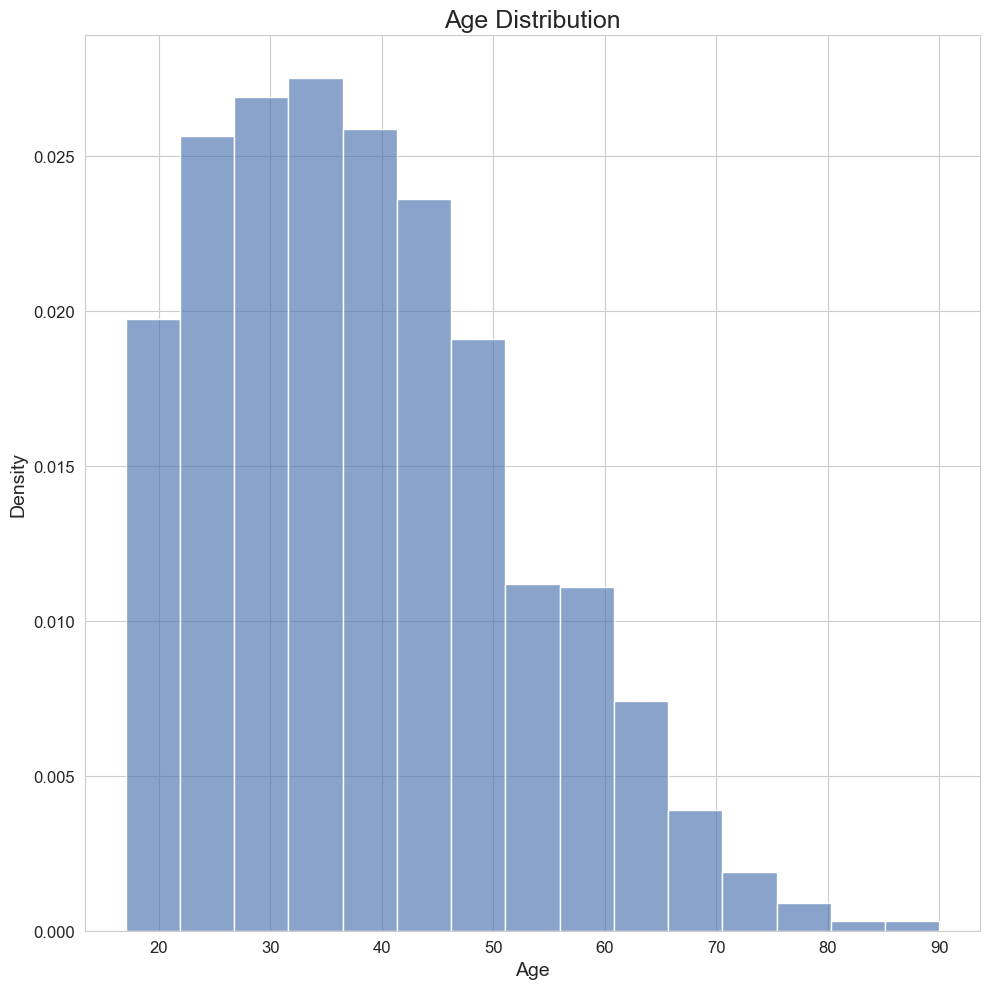

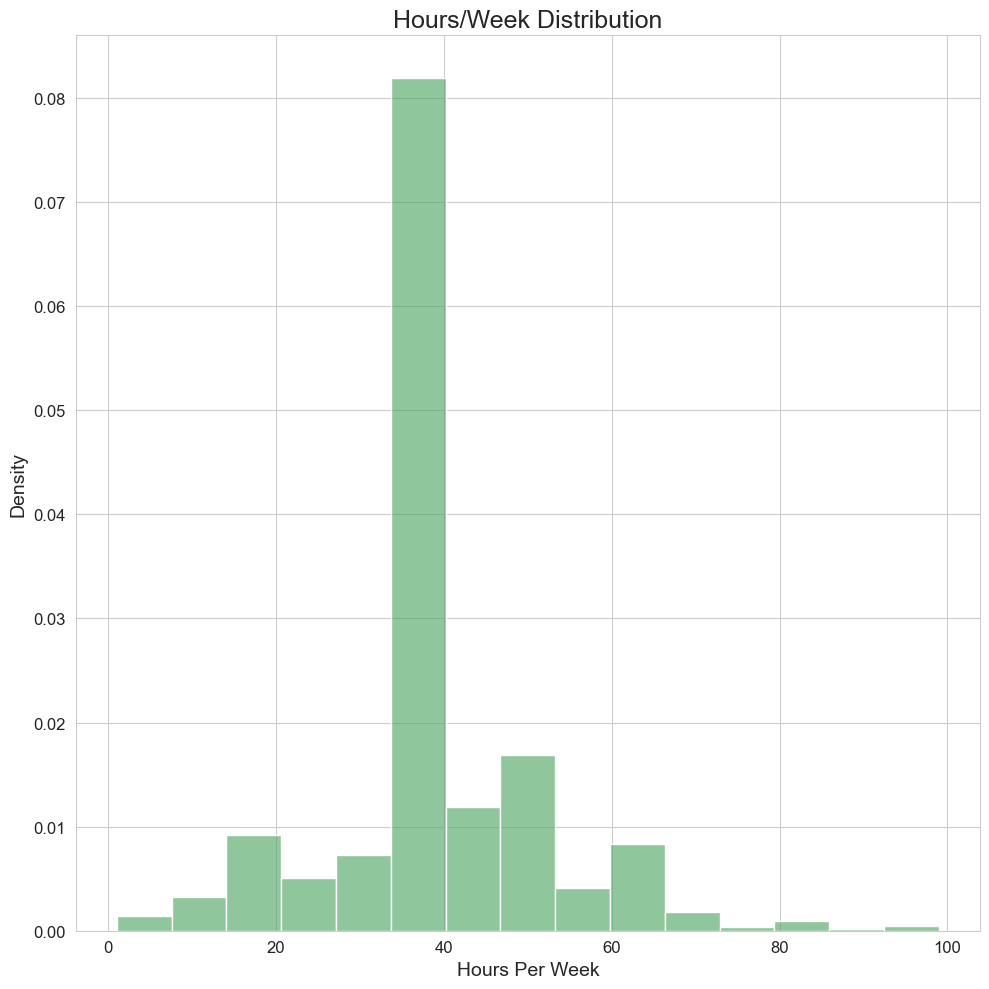

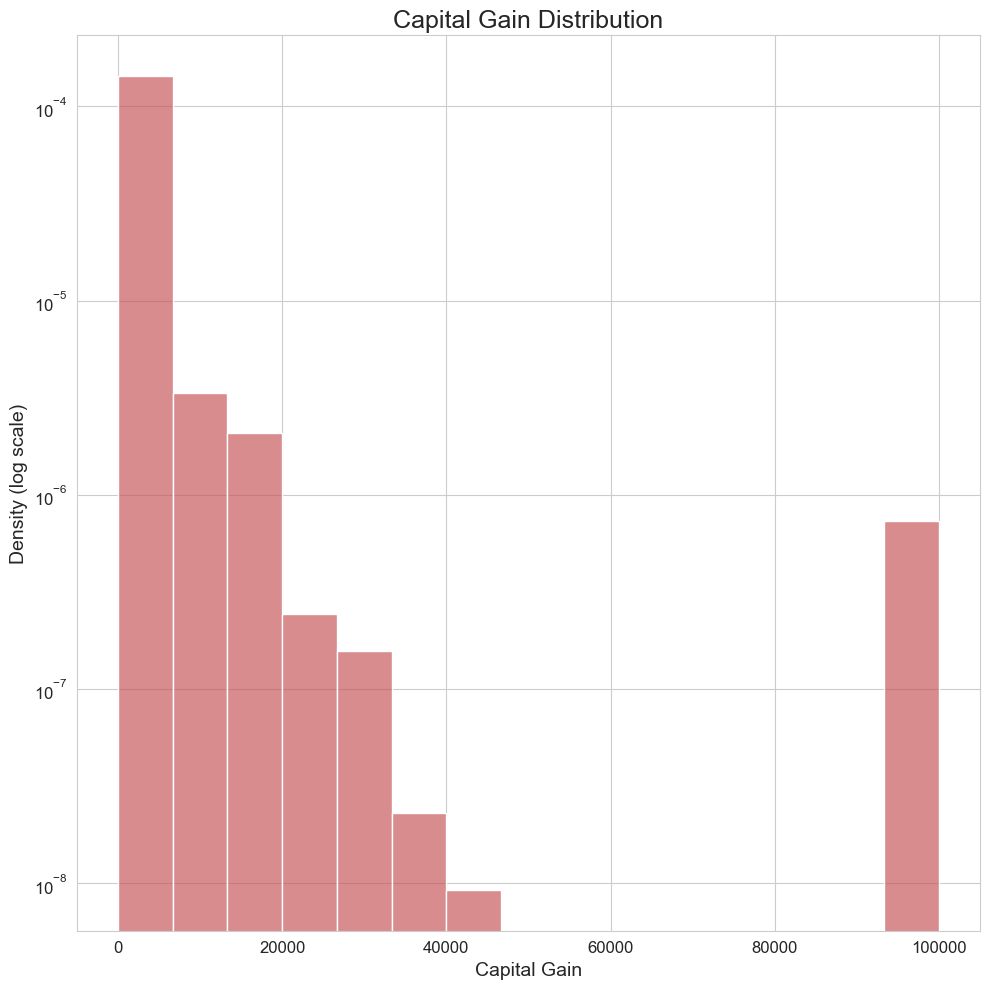

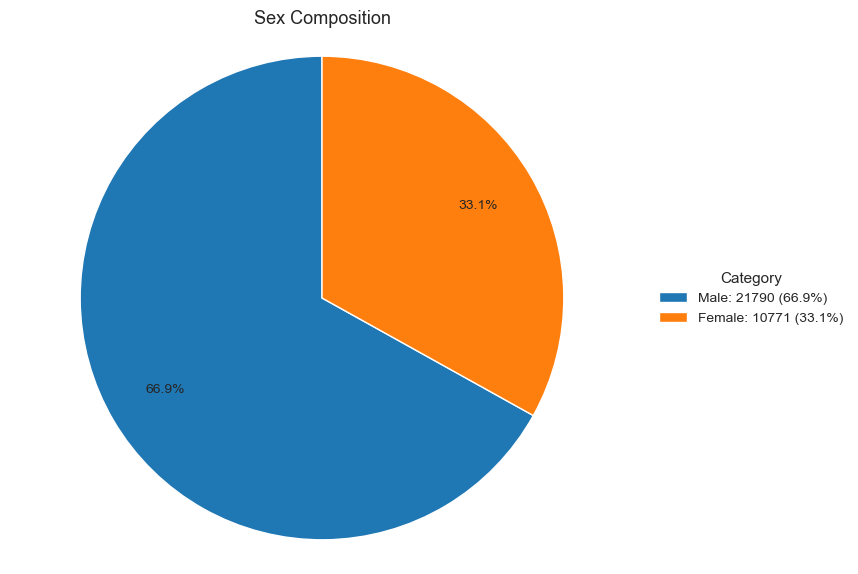

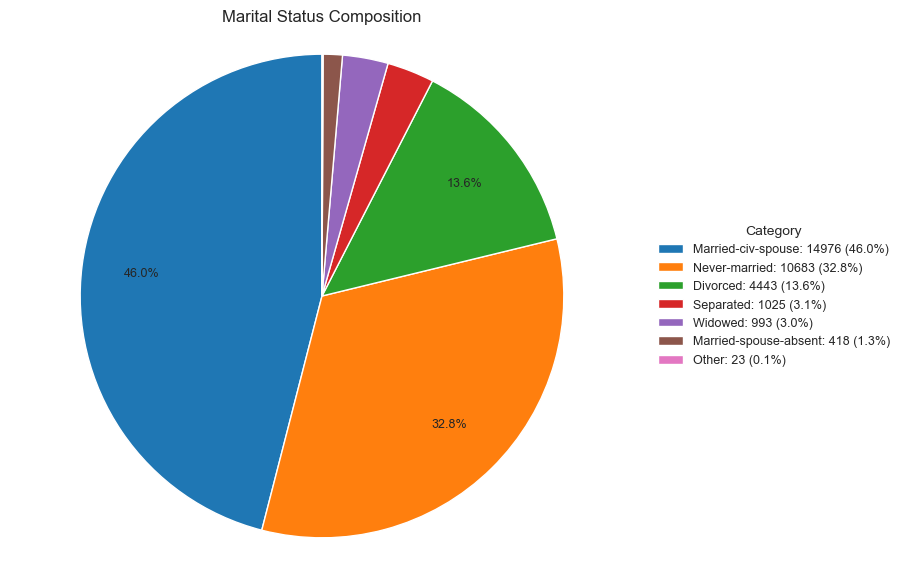

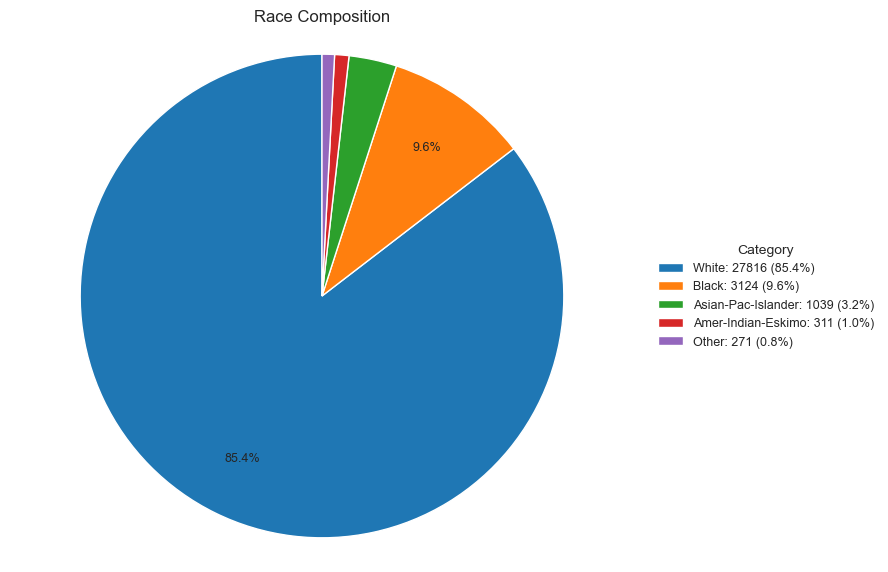

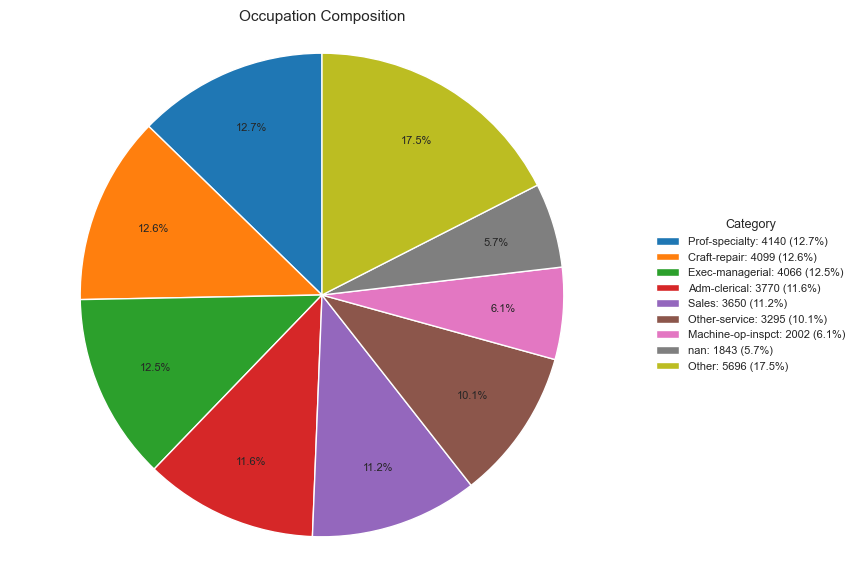

In [4]:
# Quick dataset introduction: separate plots for key numeric and categorical distributions.
viz_df = df.copy()

# 1) Age distribution (overall, no income split)
plt.figure(figsize=(10, 10))
sns.histplot(
    data=viz_df,
    x="age",
    bins=15,
    stat="density",
    alpha=0.65,
    color="#4c72b0"
    )
plt.title("Age Distribution", fontsize=hist_title_fs)
plt.xlabel("Age", fontsize=hist_label_fs)
plt.ylabel("Density", fontsize=hist_label_fs)
plt.xticks(fontsize=hist_tick_fs)
plt.yticks(fontsize=hist_tick_fs)
plt.tight_layout()
plt.show()

# 2) Weekly hours worked distribution (overall, no income split)
plt.figure(figsize=(10, 10))
sns.histplot(
    data=viz_df,
    x="hours_per_week",
    bins=15,
    stat="density",
    alpha=0.65,
    color="#55a868"
    )
plt.title("Hours/Week Distribution", fontsize=hist_title_fs)
plt.xlabel("Hours Per Week", fontsize=hist_label_fs)
plt.ylabel("Density", fontsize=hist_label_fs)
plt.xticks(fontsize=hist_tick_fs)
plt.yticks(fontsize=hist_tick_fs)
plt.tight_layout()
plt.show()

# 3) Capital gain distribution (overall, no income split)
plt.figure(figsize=(10, 10))
sns.histplot(
    data=viz_df,
    x="capital_gain",
    bins=15,
    stat="density",
    alpha=0.65,
    color="#c44e52"
    )
plt.yscale("log")
plt.title("Capital Gain Distribution", fontsize=hist_title_fs)
plt.xlabel("Capital Gain", fontsize=hist_label_fs)
plt.ylabel("Density (log scale)", fontsize=hist_label_fs)
plt.xticks(fontsize=hist_tick_fs)
plt.yticks(fontsize=hist_tick_fs)
plt.tight_layout()
plt.show()

def plot_pie_with_other(series, title, top_k=None, fontsize=10, min_pct_label=4.0):
    counts = series.value_counts(dropna=False)
    if top_k is not None and len(counts) > top_k:
        top = counts.head(top_k)
        other = counts.iloc[top_k:].sum()
        values = list(top.values) + [other]
        labels = [str(x) for x in list(top.index) + ["Other"]]
    else:
        values = counts.values
        labels = [str(x) for x in counts.index]

    total = sum(values)

    def _autopct(pct):
        return f"{pct:.1f}%" if pct >= min_pct_label else ""

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_position([0.06, 0.12, 0.52, 0.76])

    wedges, _, autotexts = ax.pie(
        values,
        labels=None,
        autopct=_autopct,
        startangle=90,
        pctdistance=0.75,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
        textprops={"fontsize": fontsize}
    )

    for text in autotexts:
        text.set_fontsize(max(fontsize - 1, 8))

    legend_labels = [f"{label}: {value} ({100 * value / total:.1f}%)" for label, value in zip(labels, values)]
    ax.legend(
        wedges,
        legend_labels,
        title="Category",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=max(fontsize - 1, 8),
        title_fontsize=fontsize
    )

    ax.set_title(title, fontsize=fontsize + 2)
    ax.axis("equal")
    plt.show()

# 4) Sex composition
plot_pie_with_other(viz_df["sex"], "Sex Composition", fontsize=11)

# 5) Marital status composition
plot_pie_with_other(viz_df["marital_status"], "Marital Status Composition", top_k=6, fontsize=10)

# 6) Race composition
plot_pie_with_other(viz_df["race"], "Race Composition", top_k=6, fontsize=10)

# 7) Occupation composition
plot_pie_with_other(viz_df["occupation"], "Occupation Composition", top_k=8, fontsize=9)